In [1]:
### Load modules and set any overarching settings.

#   Load ipython methods for module reloading at runtime.  Useful if a module
#   gets updated between running of this notebook.
%load_ext autoreload
%autoreload 2



    
#   Load my custom module paths into path.  Check to see if they are already
#   in the path; if not, add them.
customModulePath = ['/Users/mchurchf/Desktop/fromKestrel/python/WindEnergyTools']
import sys                
for i in range(len(customModulePath)):
    containsCustomModule = False
    for j in range(len(sys.path)):
        if (sys.path[j] == customModulePath[i]):
            containsCustomModule = True
    if not containsCustomModule:
        sys.path.append(customModulePath[i])




#   Load standard modules.
import os
import math
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import usefulTools





In [3]:
def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

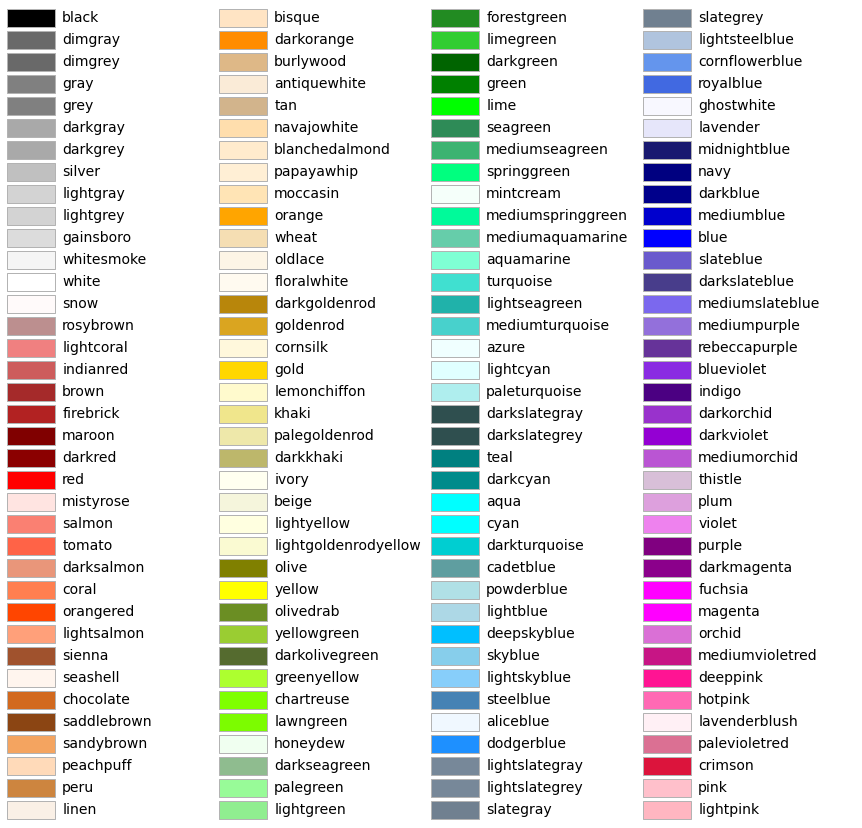

In [4]:
plot_colortable(mcolors.CSS4_COLORS)
plt.show()

In [11]:
### User input.

#   Channel and flow properties.
channelHeight = 1.0
channelLength = 4.0*channelHeight
maxVelocity = 1.0
viscosity = 1.0E-2
density = 1.0
outflowPressure = 0.0

Re = (maxVelocity * channelHeight) / viscosity

#   Angle of the flow (this will be used later for non-grid aligned cases).
angle = 0.0

#   Names of the sets of cases to be analyzed and compared.
setNames = ['Dirichlet Wall',
            'Immersed Boundary Wall']

#   Only regard CFD solution within a certain x and z range of the domain.
#   This is useful if, for example, we want to disregard the solution below the immersed boundary
#   or the inflow section where the solution adapts to the numerical solution.
eps = 1.0E-6
subDomain_x = [[0.0*channelLength,channelLength],
               [0.0*channelLength,channelLength]]
subDomain_y = [[-1.0E6,1.0E6],
               [-1.0E6,1.0E6]]
subDomain_z = [[0.0+eps,0.5*channelHeight],
               [-0.25*channelHeight-eps,0.5*channelHeight]]

#   Correct analytical solution for U = 0 at half grid cell beyond true channel.
correctForHalfGridCell = [False, True]

#   List of AMReX plt files to read in arranged in sets (outer list nest) and cases (inner list nest).
rootDir = '/Users/mchurchf/Desktop/fromKestrel/PoiseuilleFlow'
pltFiles = [
               [
                   os.path.join(rootDir,'aligned-standard-512/plt20000'),
                   os.path.join(rootDir,'aligned-standard-256/plt10000'),
                   os.path.join(rootDir,'aligned-standard-128/plt05000'),
                   os.path.join(rootDir,'aligned-standard-64/plt02500')
               ],
               [
                   os.path.join(rootDir,'aligned-ibfm-512-Domingo/plt100000'),
                   os.path.join(rootDir,'aligned-ibfm-256-Domingo/plt50000'),
                   os.path.join(rootDir,'aligned-ibfm-128-Domingo/plt50000'),
                   os.path.join(rootDir,'aligned-ibfm-64-Domingo/plt50000')
               ]
           ]

#   Symbol and line types for plots.
symbolType = ['ro','bs']
lineType = ['r-','b-']

#   Activate sanity check plots.
sanityCheckPlots = True
geometryPlots = True


#   Fonts
font = {'family' : 'serif',
        'weight' : 'normal',
        'size' : 25}

matplotlib.rc('font', **font)
plt.rcParams['text.usetex'] = True






In [3]:
### Load single AMReX plotfiles.  

#   Cases are arranged in "set"-level and "case"-level.  A group of cases is called a set.  We might have a standard
#   Dirichlet wall set of cases and a corresponding immersed boundary forcing set of cases.  Each set might have a
#   different number of cases from each other.

#   Initialize list variables.
ds = []
nCases = []

#   Get number of sets.
nSets = len(pltFiles)

for set_ in range(nSets):

    # Get number of cases per set.
    nCases.append(len(pltFiles[set_]))

    # Read plt files.
    ds_ = []
    for case_ in range(nCases[set_]):
        ds_.append(xr.open_dataset(pltFiles[set_][case_], engine='amrex', level=0))

    # Append "case"-level plt file data set to "set"-level list.
    ds.append(ds_)





i: 0 511 x: 0.00390625 3.99609375
j: 0 7 y: 0.00390625 0.05859375
k: 0 63 z: 0.00390625 0.49609375
i: 0 255 x: 0.0078125 3.9921875
j: 0 7 y: 0.0078125 0.1171875
k: 0 31 z: 0.0078125 0.4921875
i: 0 127 x: 0.015625 3.984375
j: 0 7 y: 0.015625 0.234375
k: 0 15 z: 0.015625 0.484375
i: 0 63 x: 0.03125 3.96875
j: 0 7 y: 0.03125 0.46875
k: 0 7 z: 0.03125 0.46875
i: 0 511 x: 0.00390625 3.99609375
j: 0 7 y: 0.00390625 0.05859375
k: 0 95 z: -0.24609375 0.49609375
i: 0 255 x: 0.0078125 3.9921875
j: 0 7 y: 0.0078125 0.1171875
k: 0 47 z: -0.2421875 0.4921875
i: 0 127 x: 0.015625 3.984375
j: 0 7 y: 0.015625 0.234375
k: 0 23 z: -0.234375 0.484375
i: 0 63 x: 0.03125 3.96875
j: 0 7 y: 0.03125 0.46875
k: 0 11 z: -0.21875 0.46875


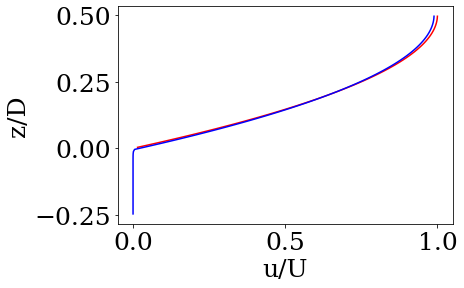

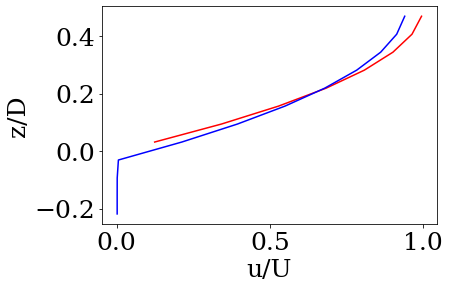

In [4]:
### Extract variables from x-array dataset.

#   Initialize list variables.
x = [];      y = [];      z = []
nx = [];     ny = [];     nz = []
dx = [];     dy = [];     dz = []
u = [];      v = [];      w = []
p = []
dpdx = [];   dpdy = [];   dpdz = []


#   Loop over sets.
for set_ in range(nSets):
    # Initialize inner list temporary storage variables.
    x_ = [];      y_ = [];      z_ = []
    nx_ = [];     ny_ = [];     nz_ = []
    dx_ = [];     dy_ = [];     dz_ = []
    u_ = [];      v_ = [];      w_ = []
    p_ = []
    dpdx_ = [];   dpdy_ = [];   dpdz_ = []

    # Loop over cases in a set.
    for case_ in range(nCases[set_]):
        
        # Get the grid coordinates.
        x__ = ds[set_][case_]['x_rho'].as_numpy().values
        y__ = ds[set_][case_]['y_rho'].as_numpy().values
        z__ = ds[set_][case_]['z_rho'].as_numpy().values

        # Only consider a subdomain.
        iMin, xMin = usefulTools.findNearestIndex(x__,subDomain_x[set_][0])
        jMin, yMin = usefulTools.findNearestIndex(y__,subDomain_y[set_][0])
        kMin, zMin = usefulTools.findNearestIndex(z__,subDomain_z[set_][0])

        iMax, xMax = usefulTools.findNearestIndex(x__,subDomain_x[set_][1])
        jMax, yMax = usefulTools.findNearestIndex(y__,subDomain_y[set_][1])
        kMax, zMax = usefulTools.findNearestIndex(z__,subDomain_z[set_][1])
                                                  
        print('i:',iMin,iMax,'x:', xMin,xMax)
        print('j:',jMin,jMax,'y:', yMin,yMax)
        print('k:',kMin,kMax,'z:', zMin,zMax)
        
        #if (disregardNegElev[set_]):
        #    kMin, zMin = usefulTools.findNearestIndex(z__,0.0)
        #    if (zMin < 0.0):
        #        kMin += 1
        #        zMin = z__[kMin]
        #else:
        #    kMin = 0
        #    zMin = z__[kMin]

        #print(kMin,zMin)

        x_.append(x__[iMin:iMax+1])
        y_.append(y__[jMin:jMax+1])
        z_.append(z__[kMin:kMax+1])
    
        # Get the grid size.
        nx_.append(len(x_[case_]))
        ny_.append(len(y_[case_]))
        nz_.append(len(z_[case_]))
    
        # Get the grid resolution.
        dx_.append(x_[case_][1] - x_[case_][0])
        dy_.append(dx_[case_])
        dz_.append(z_[case_][1] - z_[case_][0])
    
        # Get the velocity vector.
        u_.append(ds[set_][case_]['velocityx'][0,kMin:kMax+1,jMin:jMax+1,iMin:iMax+1].as_numpy().values)
        v_.append(ds[set_][case_]['velocityy'][0,kMin:kMax+1,jMin:jMax+1,iMin:iMax+1].as_numpy().values)
        w_.append(ds[set_][case_]['velocityz'][0,kMin:kMax+1,jMin:jMax+1,iMin:iMax+1].as_numpy().values)

        # Get the pressure.
        p_.append(ds[set_][case_]['p'][0,kMin:kMax+1,jMin:jMax+1,iMin:iMax+1].as_numpy().values)
    
        # Get the pressure gradient.
        dpdx_.append(ds[set_][case_]['gpx'][0,kMin:kMax+1,jMin:jMax+1,iMin:iMax+1].as_numpy().values)
        dpdy_.append(ds[set_][case_]['gpy'][0,kMin:kMax+1,jMin:jMax+1,iMin:iMax+1].as_numpy().values)
        dpdz_.append(ds[set_][case_]['gpz'][0,kMin:kMax+1,jMin:jMax+1,iMin:iMax+1].as_numpy().values)
    
        
        # The field variables get read in (z, y, x) order, so swap axes to get into (x, y, z) order
        u_[case_] = np.swapaxes(u_[case_],0,2)
        v_[case_] = np.swapaxes(v_[case_],0,2)
        w_[case_] = np.swapaxes(w_[case_],0,2)
        
        p_[case_] = np.swapaxes(p_[case_],0,2)
    
        dpdx_[case_] = np.swapaxes(dpdx_[case_],0,2)
        dpdy_[case_] = np.swapaxes(dpdy_[case_],0,2)
        dpdz_[case_] = np.swapaxes(dpdz_[case_],0,2)


    # Append the "case"-level lists to the "set"-level lists.
    x.append(x_);         y.append(y_);          z.append(z_)
    u.append(u_);         v.append(v_);          w.append(w_)
    p.append(p_);
    dpdx.append(dpdx_);   dpdy.append(dpdy_);    dpdz.append(dpdz_)

    nx.append(np.asarray(nx_));       ny.append(np.asarray(ny_));        nz.append(np.asarray(nz_))
    dx.append(np.asarray(dx_));       dy.append(np.asarray(dy_));        dz.append(np.asarray(dz_))


# Plot a profile of velocity as a sanity check
if (sanityCheckPlots):
    case_ = 0
    figNum = 0
    plt.figure(figNum)
    plt.plot(u[0][case_][-1,0,:],z[0][case_],lineType[0])
    plt.plot(u[1][case_][-1,0,:],z[1][case_],lineType[1])
    plt.xlabel('u/U')
    plt.ylabel('z/D')
    
    case_ = 3
    figNum += 1
    plt.figure(figNum)
    plt.plot(u[0][case_][-1,0,:],z[0][case_],lineType[0])
    plt.plot(u[1][case_][-1,0,:],z[1][case_],lineType[1])
    plt.xlabel('u/U')
    plt.ylabel('z/D')






In [5]:
### Compute the analytical solution and the maximum and RMS error.

#   Initialize the list variables.
uExact = [];       vExact = [];       wExact = []
pExact = []
dpdxExact = [];    dpdyExact = [];    dpdzExact = []

uError = [];       vError = [];       wError = []
pError = []
dpdxError = [];    dpdyError = [];    dpdzError = []

uErrorMax = [];       vErrorMax = [];      wErrorMax = []
pErrorMax = []
dpdxErrorMax = [];    dpdyErrorMax = [];    dpdzErrorMax = []

uErrorRMS = [];       vErrorRMS = [];       wErrorRMS = []
pErrorRMS = []
dpdxErrorRMS = [];    dpdyErrorRMS = [];    dpdzErrorRMS = []

#   Loop over sets.
for set_ in range(nSets):
    # Initialize inner list temporary storage variables.
    uExact_ = [];       vExact_ = [];       wExact_ = []
    pExact_ = []
    dpdxExact_ = [];    dpdyExact_ = [];    dpdzExact_ = []
    
    uError_ = [];       vError_ = [];       wError_ = []
    pError_ = []
    dpdxError_ = [];    dpdyError_ = [];    dpdzError_ = []
    
    uErrorMax_ = [];       vErrorMax_ = [];      wErrorMax_ = []
    pErrorMax_ = []
    dpdxErrorMax_ = [];    dpdyErrorMax_ = [];    dpdzErrorMax_ = []
    
    uErrorRMS_ = [];       vErrorRMS_ = [];       wErrorRMS_ = []
    pErrorRMS_ = []
    dpdxErrorRMS_ = [];    dpdyErrorRMS_ = [];    dpdzErrorRMS_ = []

    # Loop over cases in a set.
    for case_ in range(nCases[set_]):

        # Compute parameters for parabolic solution of u-velocity.
        if (correctForHalfGridCell[set_]):
            zl = -(0.5 * dz[set_][case_]) / channelHeight
            zu =  (0.5 * dz[set_][case_] + channelHeight) / channelHeight
        else:
            zl = 0.0
            zu = 1.0
        dpdxE = ((4.0/(3.0*Re)) / ((1.0/3.0)*(zu**3 - zl**3) - 0.5*((zu + zl)*(zu**2 - zl**2)) + zu*zl*(zu - zl)))
        a = 0.5 * Re * dpdxE
        b = -a * (zl + zu)
        c = a * zl * zu

        
        dpdxE *= (density * maxVelocity * maxVelocity / channelHeight)

        # This is the exact solution for all variables except u-velocity.  We are initializing u here.
        uExact_.append(np.zeros(np.shape(u[set_][case_])))
        vExact_.append(np.zeros(np.shape(v[set_][case_])))
        wExact_.append(np.zeros(np.shape(w[set_][case_])))
        pExact_.append(np.zeros(np.shape(p[set_][case_])))
        dpdxExact_.append(np.ones(np.shape(dpdx[set_][case_])) * dpdxE)
        dpdyExact_.append(np.zeros(np.shape(dpdy[set_][case_])))
        dpdzExact_.append(np.zeros(np.shape(dpdz[set_][case_])))
        
        # Exact parabolic solution for u-velocity.
        for k in range(nz[set_][case_]):
            if ((z[set_][case_][k]/channelHeight > 0.0) and (z[set_][case_][k]/channelHeight < 0.5)):
                uExact_[case_][:,:,k] = maxVelocity * (a * ((z[set_][case_][k]/channelHeight)**2) \
                                                     + b * (z[set_][case_][k]/channelHeight) \
                                                     + c)
            else:
                uExact_[case_][:,:,k] = 0.0

        # Exact linear solution for pressure.
        for k in range(nz[set_][case_]):
            for j in range(ny[set_][case_]):
                if ((z[set_][case_][k]/channelHeight > 0.0) and (z[set_][case_][k]/channelHeight < 0.5)):
                    pExact_[case_][:,j,k] = (dpdxE * (x[set_][case_] - channelLength)) + outflowPressure
                else:
                    pExact_[case_][:,j,k] = outflowPressure
            
        

        # Error is actual minus exact.
        uError_.append(u[set_][case_] - uExact_[case_])
        vError_.append(v[set_][case_] - vExact_[case_])
        wError_.append(w[set_][case_] - wExact_[case_])
        pError_.append(p[set_][case_] - pExact_[case_])
        dpdxError_.append(dpdx[set_][case_] - dpdxExact_[case_])
        dpdyError_.append(dpdy[set_][case_] - dpdyExact_[case_])
        dpdzError_.append(dpdz[set_][case_] - dpdzExact_[case_])

        # Compute max error as maximum absolute error among all grid cells.
        uErrorMax_.append(np.max(np.abs(uError_[case_])))
        vErrorMax_.append(np.max(np.abs(vError_[case_])))
        wErrorMax_.append(np.max(np.abs(wError_[case_])))
        pErrorMax_.append(np.max(np.abs(pError_[case_])))
        dpdxErrorMax_.append(np.max(np.abs(dpdxError_[case_])))
        dpdyErrorMax_.append(np.max(np.abs(dpdyError_[case_])))
        dpdzErrorMax_.append(np.max(np.abs(dpdzError_[case_])))

        # Compute root-mean-square error as square-root of the mean of the squared error over all grid cells.
        uErrorRMS_.append(np.sqrt(np.mean(np.square(uError_[case_]))))
        vErrorRMS_.append(np.sqrt(np.mean(np.square(vError_[case_]))))
        wErrorRMS_.append(np.sqrt(np.mean(np.square(wError_[case_]))))
        pErrorRMS_.append(np.sqrt(np.mean(np.square(pError_[case_]))))
        dpdxErrorRMS_.append(np.sqrt(np.mean(np.square(dpdxError_[case_]))))
        dpdyErrorRMS_.append(np.sqrt(np.mean(np.square(dpdyError_[case_]))))
        dpdzErrorRMS_.append(np.sqrt(np.mean(np.square(dpdzError_[case_]))))

    
    # Append "case"-level lists into "set"-level lists.
    uExact.append(uExact_);          vExact.append(vExact_);          wExact.append(wExact_);
    pExact.append(pExact_);
    dpdxExact.append(dpdxExact_);    dpdyExact.append(dpdyExact_);    dpdzExact.append(dpdzExact_);
    
    uError.append(uError_);          vError.append(vError_);          wError.append(wError_);
    pError.append(pError_);
    dpdxError.append(dpdxError_);    dpdyError.append(dpdyError_);    dpdzError.append(dpdzError_);
    
    uErrorMax.append(np.asarray(uErrorMax_));          vErrorMax.append(np.asarray(vErrorMax_));          wErrorMax.append(np.asarray(wErrorMax_));
    pErrorMax.append(np.asarray(pErrorMax_));
    dpdxErrorMax.append(np.asarray(dpdxErrorMax_));    dpdyErrorMax.append(np.asarray(dpdyErrorMax_));    dpdzErrorMax.append(np.asarray(dpdzErrorMax_));
    
    uErrorRMS.append(np.asarray(uErrorRMS_));          vErrorRMS.append(np.asarray(vErrorRMS_));          wErrorRMS.append(np.asarray(wErrorRMS_));
    pErrorRMS.append(np.asarray(pErrorRMS_));
    dpdxErrorRMS.append(np.asarray(dpdxErrorRMS_));    dpdyErrorRMS.append(np.asarray(dpdyErrorRMS_));    dpdzErrorRMS.append(np.asarray(dpdzErrorRMS_));




    

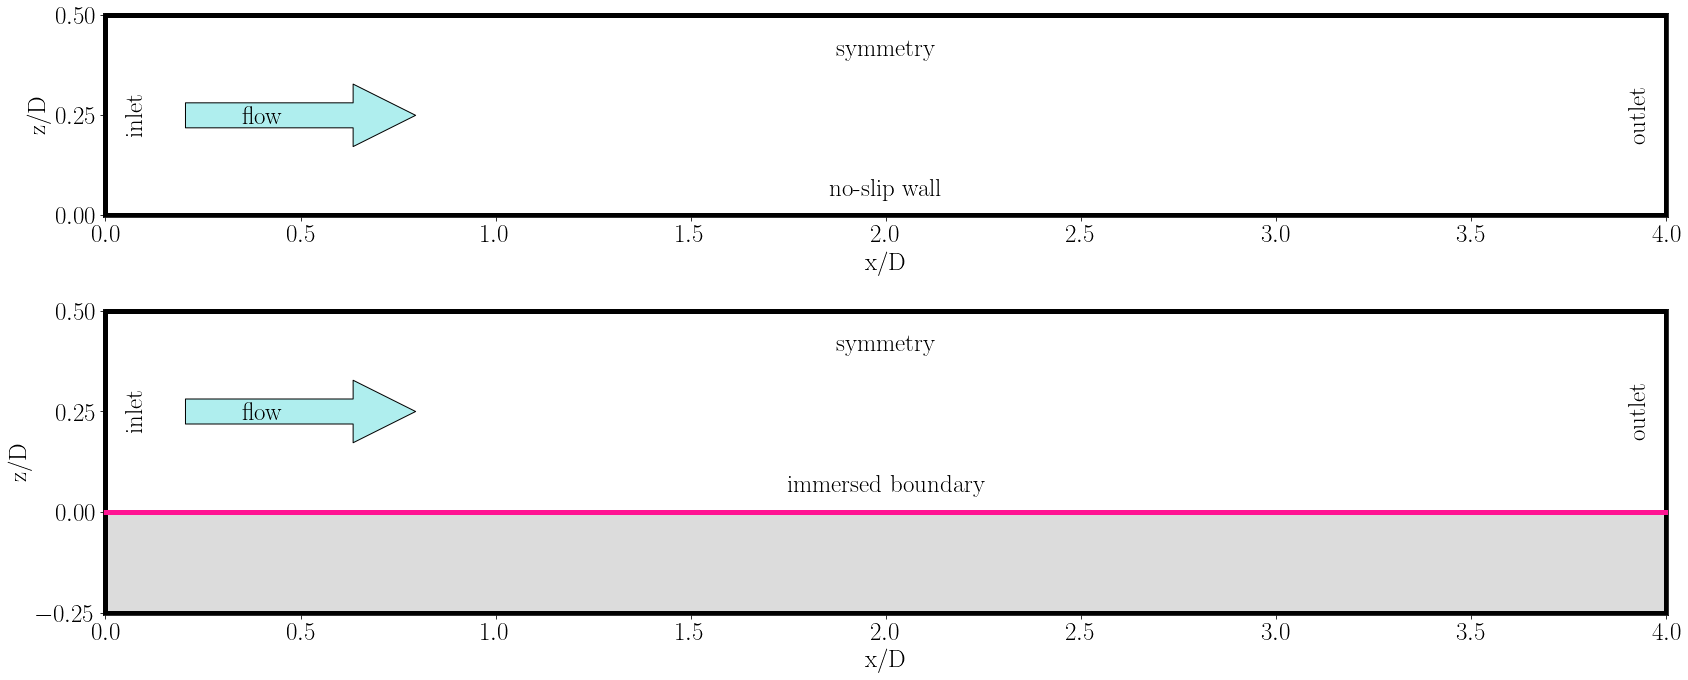

In [69]:
### Plots of the domain geometry/setup

tol = 5.0E-3
figLength = 24.0
figAspect = 5.0/24.0
fontSize = 25.0

sets = [0, 1]
cases = [0, 0]



# Do some initial calculation of sizes of domains to help in sizing of figure
nSets = len(sets)
Lz = []
for i in range(nSets):
    set_ = sets[i]
    case_ = cases[i]

    zMin = np.min(z[set_][case_]) - 0.5*dz[set_][case_]
    zMax = np.max(z[set_][case_]) + 0.5*dz[set_][case_]
    Lz.append(zMax-zMin)
    
heightRatio = []
for i in range(nSets):
    heightRatio.append(Lz[i]/min(Lz))
    
    

# Set up the axes
fig, axs = plt.subplots(nrows=nSets,figsize=(figLength,figAspect*figLength*nSets),
                        gridspec_kw={'height_ratios': heightRatio})



# Plot the domains
for i in range(nSets):
    set_ = sets[i]
    case_ = cases[i]


    # Get the grid information.
    xMin = np.min(x[set_][case_]) - 0.5*dx[set_][case_]
    xMax = np.max(x[set_][case_]) + 0.5*dx[set_][case_]
    zMin = np.min(z[set_][case_]) - 0.5*dz[set_][case_]
    zMax = np.max(z[set_][case_]) + 0.5*dz[set_][case_]
    #print(z[set_][case_])
    #print(dz[set_][case_])
    #print(xMin,xMax,zMin,zMax)


    # Plot the outline of the domain.
    axs[i].plot([xMin,xMax,xMax,xMin,xMin],
                [zMin,zMin,zMax,zMax,zMin],'k-',linewidth=5.0)


    # Set the axis tick marks and add indicators of the immersed boundary.
    if (zMin >= 0.0):
        axs[i].set_yticks([0.0, 0.5*zMax, zMax])
    else:
        axs[i].plot([xMin,xMax],[0.0, 0.0],color='deeppink',linewidth=5.0)
        rect = plt.Rectangle((xMin, zMin), xMax-xMin, -zMin, facecolor="gainsboro", alpha=1.0)
        axs[i].add_patch(rect)
        axs[i].set_yticks([zMin, 0.0, 0.5*zMax, zMax])
        
    axs[i].set_xlim((xMin-tol,xMax+tol))
    axs[i].set_ylim((zMin-tol,zMax+tol))

    
    # Add boundary condition text.
    axs[i].text(0.05,0.5*zMax,'inlet',rotation='vertical',verticalalignment='center',fontsize=fontSize)
    axs[i].text(xMax-0.1,0.5*zMax,'outlet',rotation='vertical',verticalalignment='center',fontsize=fontSize)
    
    if (zMin >= 0.0):
        axs[i].text(0.5*xMax,0.05,'no-slip wall',rotation='horizontal',horizontalalignment='center',fontsize=fontSize)
    else:
        axs[i].text(0.5*xMax,0.05,'immersed boundary',rotation='horizontal',horizontalalignment='center',fontsize=fontSize)
        
    axs[i].text(0.5*xMax,0.40,'symmetry',rotation='horizontal',horizontalalignment='center',fontsize=fontSize)
    
    
    # Add the flow direction arrow
    arrow = mpatches.FancyArrowPatch((0.2, 0.5*zMax), (0.8, 0.25),
                                 mutation_scale=125,facecolor='paleturquoise')
    axs[i].add_patch(arrow)
    axs[i].text(0.35,0.229,'flow',fontsize=fontSize)

    
    # Add the axis labels
    axs[i].set_xlabel('x/D',fontweight='normal')
    axs[i].set_ylabel('z/D',fontweight='normal')
    
    fig.tight_layout()




# Save the image file
plt.savefig(os.path.join('figures','caseSetup.png'),bbox_inches='tight')





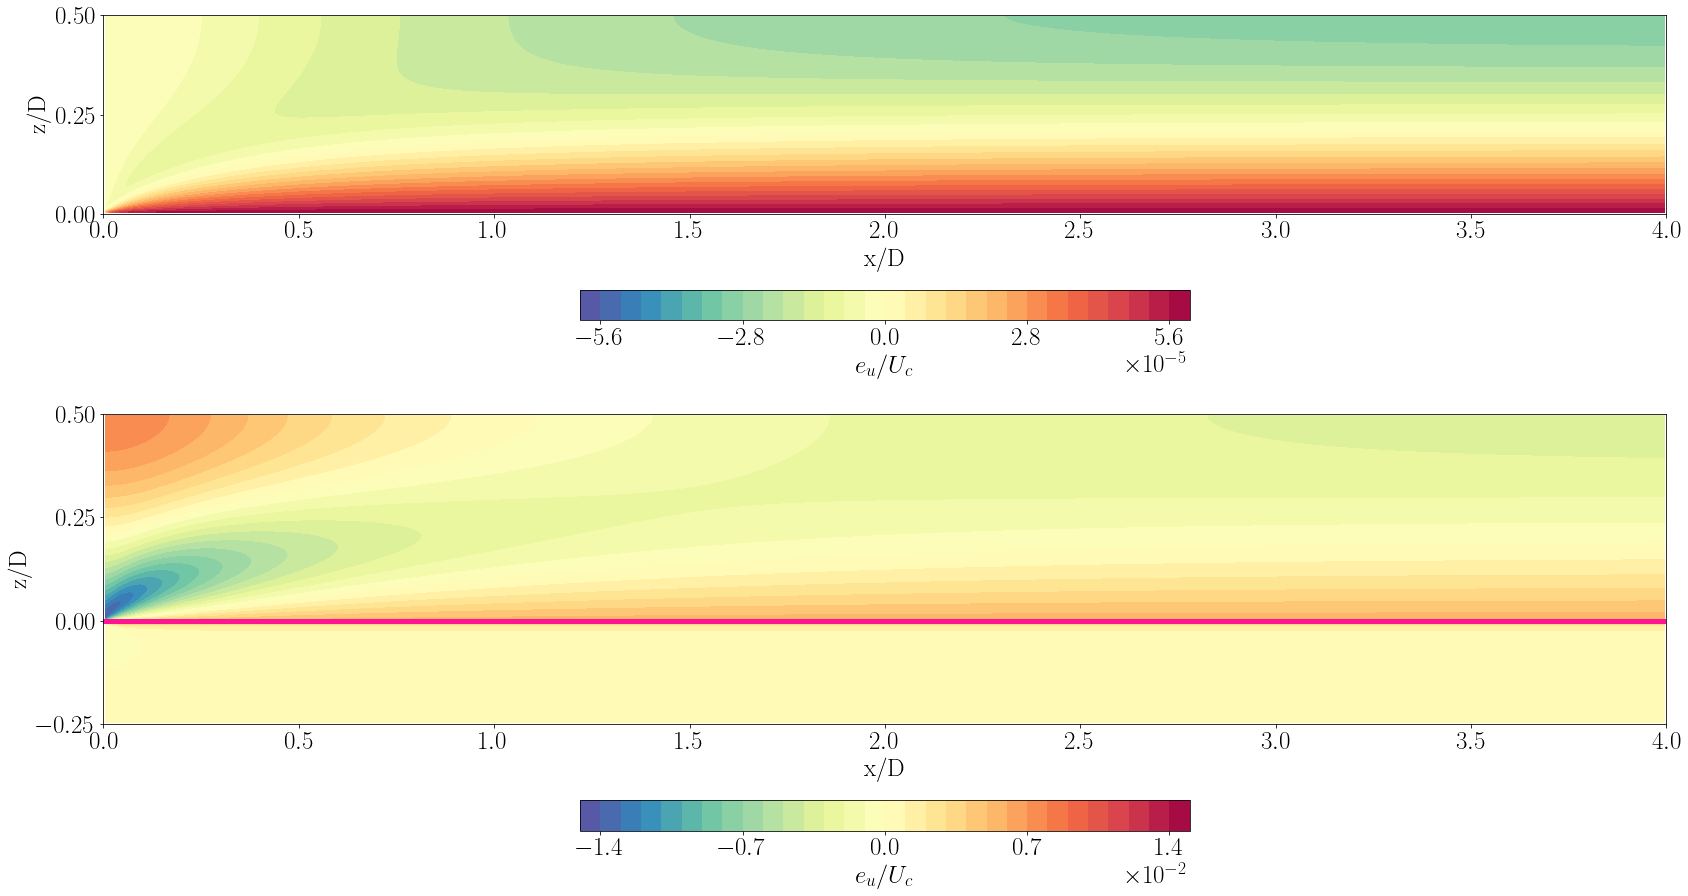

In [70]:
### Plots of contours of streamwise velocity error

tol = 0.0
figLength = 24.0
figAspect = 6.5/24.0
fontSize = 25.0
nContourLevels = 31
#colorMap = 'RdBu_r'
colorMap = 'Spectral_r'

sets = [0, 1]
cases = [0, 0]



# Do some initial calculation of sizes of domains to help in sizing of figure
nSets = len(sets)
Lz = []
for i in range(nSets):
    set_ = sets[i]
    case_ = cases[i]

    zMin = np.min(z[set_][case_]) - 0.5*dz[set_][case_]
    zMax = np.max(z[set_][case_]) + 0.5*dz[set_][case_]
    Lz.append(zMax-zMin)

heightRatioFac = 0.18
heightRatio = []
for i in range(nSets):
    heightRatio.append((Lz[i]+heightRatioFac)/(min(Lz)+heightRatioFac))
    

# Set up the axes
fig, axs = plt.subplots(nrows=nSets,figsize=(figLength,figAspect*figLength*nSets),
                        gridspec_kw={'height_ratios': heightRatio})


# Plot the domains
for i in range(nSets):
    set_ = sets[i]
    case_ = cases[i]

    
    # Get the mesh
    xx,zz = np.meshgrid(x[set_][case_],z[set_][case_])
    xx = np.transpose(xx)
    zz = np.transpose(zz)
    
    xMin = np.min(x[set_][case_]) - 0.5*dx[set_][case_]
    xMax = np.max(x[set_][case_]) + 0.5*dx[set_][case_]
    zMin = np.min(z[set_][case_]) - 0.5*dz[set_][case_]
    zMax = np.max(z[set_][case_]) + 0.5*dz[set_][case_]

    
    # Set the contour levels to nice round numbers and equal positive and negative
    vmax = uErrorMax[set_][case_]
    exponent = np.floor(np.log10(abs(vmax)))
    vmax = vmax/(10.0**exponent)
    vmax = np.round(vmax,decimals=1)
    vmax = vmax*(10.0**exponent)
    vmin = -vmax
    customLevels = np.linspace(vmin, vmax, nContourLevels)

    
    # Plot the contours of error.
    cont = axs[i].contourf(xx,zz,uError[set_][case_][:,0,:],cmap=colorMap,levels=customLevels)


    # Put on the colorbar and get it set to look just right
    cbar = plt.colorbar(cont, ax=axs[i], location='bottom', fraction=0.1/heightRatio[i], pad=0.25/heightRatio[i], label=r'$e_u/U_c$')
    cbar.ax.locator_params(nbins=5)           # Limit to 5 colorbar labels
    cbar.formatter.set_powerlimits((0, 0))    # Do this to get x 10^3 instead of 1e3
    cbar.formatter.set_useMathText(True) 

    
    # Set the axis tickmarks and draw the immersed boundary line.
    if (zMin >= 0.0):
        axs[i].set_yticks([0.0, 0.5*zMax, zMax])
    else:
        axs[i].plot([xMin,xMax],[0.0, 0.0],color='deeppink',linewidth=5.0)
        axs[i].set_yticks([zMin, 0.0, 0.5*zMax, zMax])
        
    axs[i].set_xlim((xMin-tol,xMax+tol))
    axs[i].set_ylim((zMin-tol,zMax+tol))
    
    
    # Add the axis labels
    axs[i].set_xlabel('x/D',fontweight='normal')
    axs[i].set_ylabel('z/D',fontweight='normal')
    
    fig.tight_layout()




# Save the image file
plt.savefig(os.path.join('figures','errorContours.png'),bbox_inches='tight')





In [ ]:
# Set up the axes
fig, axs = plt.subplots(nrows=2,figsize=(24,10),gridspec_kw={'height_ratios': [1.0, 1.5]})

set_ = 0
case_ = 0
figNum = 0
plt.figure(figNum,figsize=(24,3))
xx,zz = np.meshgrid(x[set_][case_],z[set_][case_])
xx = np.transpose(xx)
zz = np.transpose(zz)
plt.contourf(xx,zz,uError[set_][case_][:,0,:],cmap='RdBu_r',levels=51,vmin=-uErrorMax[set_][case_],vmax=uErrorMax[set_][case_])
cbar = plt.colorbar()
plt.xlabel('x/D')
plt.ylabel('z/D')
cbar.set_label(r'$u_{error}/U_c$', rotation=270, labelpad=25)

set_ = 1
case_ = 0
figNum += 1
plt.figure(figNum,figsize=(24,3))
xx,zz = np.meshgrid(x[set_][case_],z[set_][case_])
xx = np.transpose(xx)
zz = np.transpose(zz)
plt.contourf(xx,zz,uError[set_][case_][:,0,:],cmap='RdBu_r',levels=51,vmin=-uErrorMax[set_][case_],vmax=uErrorMax[set_][case_])
cbar = plt.colorbar()
plt.xlabel('x/D')
plt.ylabel('z/D')
cbar.set_label(r'$u_{error}/U_c$', rotation=270, labelpad=25)

set_ = 1
case_ = 0
figNum += 1
plt.figure(figNum,figsize=(24,3))
xx,zz = np.meshgrid(x[set_][case_],z[set_][case_])
xx = np.transpose(xx)
zz = np.transpose(zz)
plt.contourf(xx,zz,u[set_][case_][:,0,:],cmap='viridis',levels=51,vmin=0.0,vmax=1.0)
cbar = plt.colorbar()
plt.xlabel('x/D')
plt.ylabel('z/D')
cbar.set_label(r'$u/U_c$', rotation=270, labelpad=25)

[ 1.98746366 -0.97089857]
2.0
[ 0.79548292 -2.20296486]
1.0


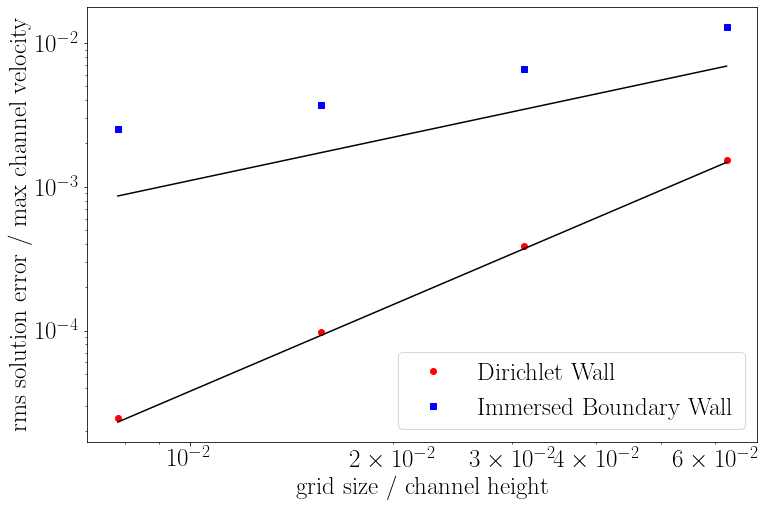

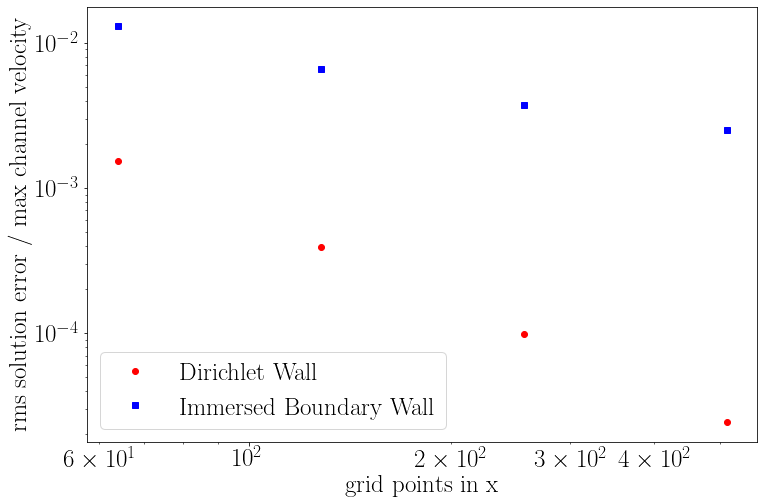

In [71]:
### Plot error convergence.
figSize = (12,8)

uErrorRMSFit = []
for set_ in range(nSets):
    uErrorRMSFit.append(np.zeros(np.shape(uErrorRMS[set_])))
    coeffs = np.polyfit(np.log(dx[set_]),np.log(uErrorRMS[set_]),1)
    print(coeffs)
    m = np.round(coeffs[0],0)
    print(m)
    
    uErrorRMSFit[set_] = np.exp(m * np.log(dx[set_]) + coeffs[1])
    if (set_ == 1):
        uErrorRMSFit[set_] = np.exp(m * np.log(dx[set_]) + coeffs[1])

figNum = 0
plt.figure(figNum,figsize=figSize)
for set_ in range(nSets):
    plt.loglog(dx[set_]/channelHeight,uErrorRMS[set_]/maxVelocity,symbolType[set_])
plt.xlabel('grid size / channel height')
plt.ylabel('rms solution error / max channel velocity')
plt.legend(setNames)

plt.loglog(dx[0]/channelHeight,uErrorRMSFit[0]/maxVelocity,'k-')
plt.loglog(dx[1]/channelHeight,uErrorRMSFit[1]/maxVelocity,'k-')

               
figNum += 1
plt.figure(figNum,figsize=figSize)
for set_ in range(nSets):
    plt.loglog(nx[set_],uErrorRMS[set_]/maxVelocity,symbolType[set_])
plt.xlabel('grid points in x')
plt.ylabel('rms solution error / max channel velocity')
plt.legend(setNames)



               


Text(0.5, 1.0, 'nz = 16')

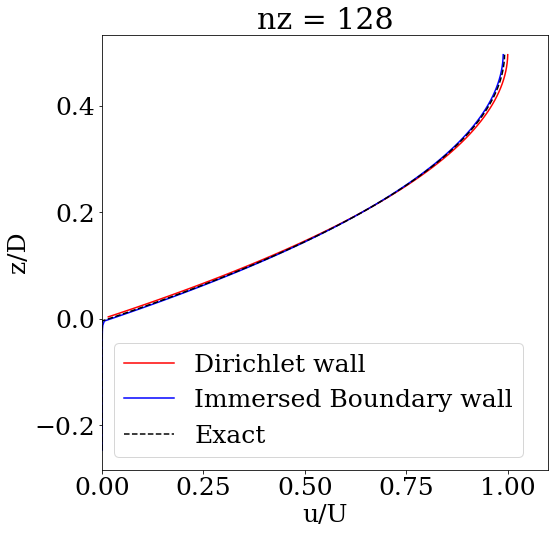

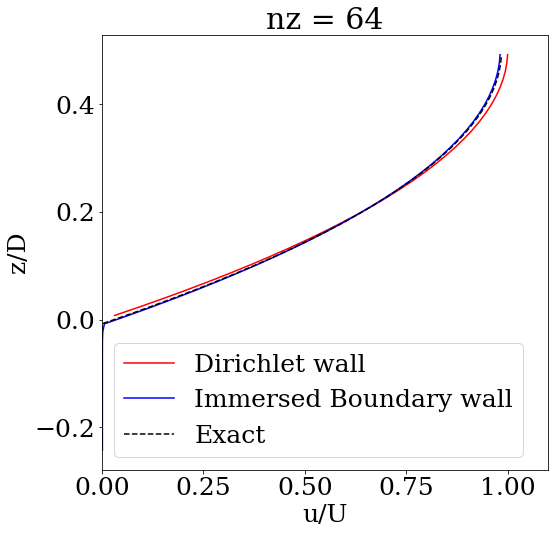

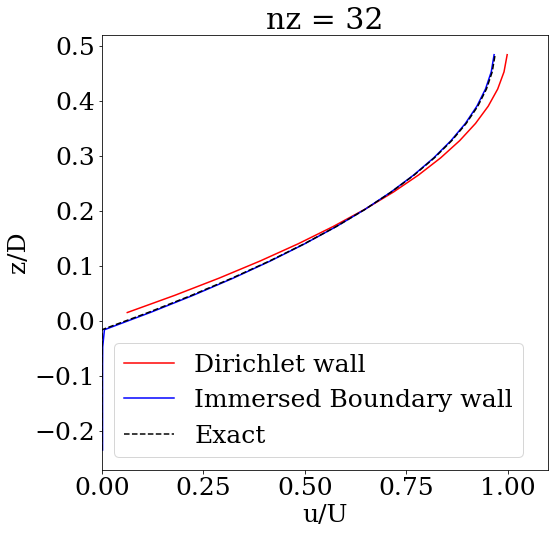

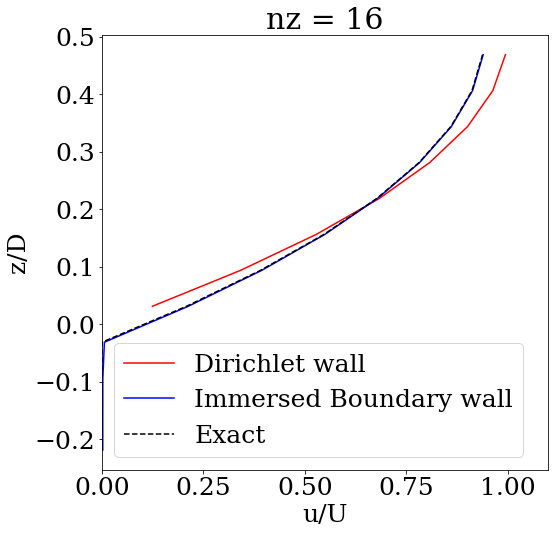

In [52]:
### Plot some profiles convergence.
figSize = (8,8)

case_ = 0
figNum = 0
plt.figure(figNum,figsize=figSize)
for set_ in range(nSets):
    plt.plot(u[set_][case_][-1,0,:],z[set_][case_],lineType[set_])
plt.plot(uExact[set_][case_][-1,0,:],z[set_][case_],'k--')
plt.xlim(0,1.1)
#plt.ylim(0,0.5)
plt.xlabel('u/U')
plt.ylabel('z/D')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))

case_ = 1
figNum += 1
plt.figure(figNum,figsize=figSize)
for set_ in range(nSets):
    plt.plot(u[set_][case_][-1,0,:],z[set_][case_],lineType[set_])
plt.plot(uExact[set_][case_][-1,0,:],z[set_][case_],'k--')
plt.xlim(0,1.1)
#plt.ylim(0,0.5)
plt.xlabel('u/U')
plt.ylabel('z/D')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))

case_ = 2
figNum += 1
plt.figure(figNum,figsize=figSize)
for set_ in range(nSets):
    plt.plot(u[set_][case_][-1,0,:],z[set_][case_],lineType[set_])
plt.plot(uExact[set_][case_][-1,0,:],z[set_][case_],'k--')
plt.xlim(0,1.1)
#plt.ylim(0,0.5)
plt.xlabel('u/U')
plt.ylabel('z/D')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))

case_ = 3
figNum += 1
plt.figure(figNum,figsize=figSize)
for set_ in range(nSets):
    plt.plot(u[set_][case_][-1,0,:],z[set_][case_],lineType[set_])
plt.plot(uExact[set_][case_][-1,0,:],z[set_][case_],'k--')
plt.xlim(0,1.1)
#plt.ylim(0,0.5)
plt.xlabel('u/U')
plt.ylabel('z/D')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))





Text(0.5, 1.0, 'nz = 16')

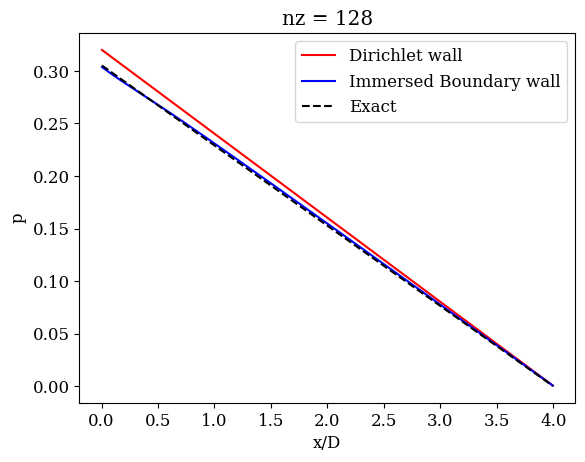

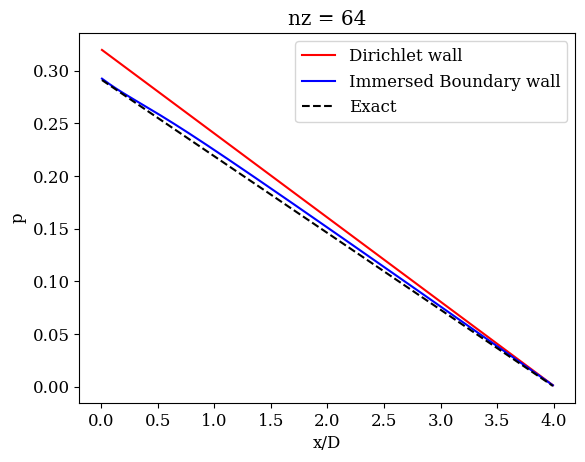

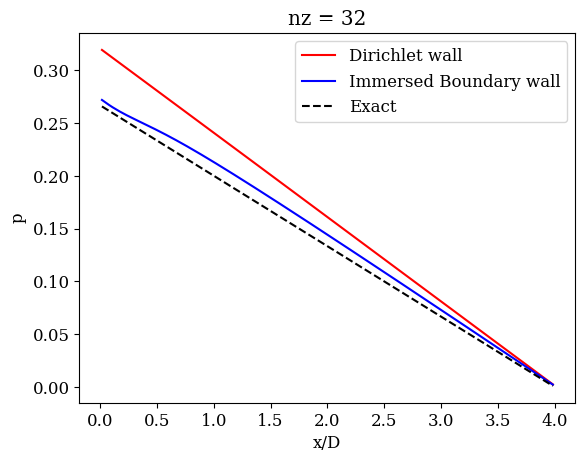

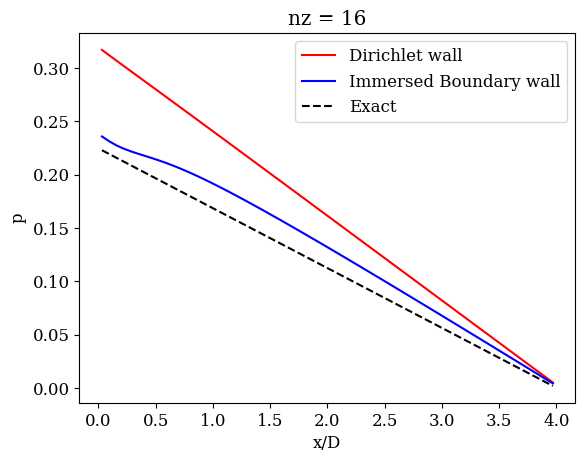

In [16]:
### Plot some profiles convergence.

case_ = 0
figNum = 0
plt.figure(figNum)
for set_ in range(nSets):
    plt.plot(x[set_][case_]/channelHeight,p[set_][case_][:,0,-1],lineType[set_])
plt.plot(x[set_][case_]/channelHeight,pExact[set_][case_][:,0,-1],'k--')
plt.xlabel('x/D')
plt.ylabel('p')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))

case_ = 1
figNum += 1
plt.figure(figNum)
for set_ in range(nSets):
    plt.plot(x[set_][case_]/channelHeight,p[set_][case_][:,0,-1],lineType[set_])
plt.plot(x[set_][case_]/channelHeight,pExact[set_][case_][:,0,-1],'k--')
plt.xlabel('x/D')
plt.ylabel('p')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))

case_ = 2
figNum += 1
plt.figure(figNum)
for set_ in range(nSets):
    plt.plot(x[set_][case_]/channelHeight,p[set_][case_][:,0,-1],lineType[set_])
plt.plot(x[set_][case_]/channelHeight,pExact[set_][case_][:,0,-1],'k--')
plt.xlabel('x/D')
plt.ylabel('p')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))

case_ = 3
figNum += 1
plt.figure(figNum)
for set_ in range(nSets):
    plt.plot(x[set_][case_]/channelHeight,p[set_][case_][:,0,-1],lineType[set_])
plt.plot(x[set_][case_]/channelHeight,pExact[set_][case_][:,0,-1],'k--')
plt.xlabel('x/D')
plt.ylabel('p')
plt.legend(setNames + ['Exact'])
plt.title('nz = ' + str(int(channelHeight/np.asarray(dx[set_][case_]))))